# Day 3 - Exploratory Data Analysis (EDA)

## Placement Prediction & Recommendation Platform

This notebook performs exploratory data analysis (EDA) on the generated placement dataset stored in MySQL.

The objective is to understand student demographics, academic performance, placement trends, company recruitment patterns, and skill distributions through statistical analysis and visualizations.

The insights obtained from this notebook will be used for:

- Machine Learning Model Development
- Placement Prediction
- Recommendation System
- Dashboard Development

## Objectives

The primary objectives of this notebook are:

- Analyze the overall dataset
- Perform data quality assessment
- Study student demographics
- Analyze academic performance
- Explore placement trends
- Analyze company hiring patterns
- Study technical skill distributions
- Generate SQL-based business insights
- Identify important features for machine learning

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import mysql.connector

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

## Connect to MySQL

In [2]:
import os

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=os.getenv("MYSQL_PASSWORD"),
    database="placement_platform"
)

cursor = conn.cursor()

print("✅ Connected Successfully!")

Connected Successfully!


## Load Tables

In [3]:
students = pd.read_sql("SELECT * FROM Students", conn)

companies = pd.read_sql("SELECT * FROM Companies", conn)

roles = pd.read_sql("SELECT * FROM Roles", conn)

skills = pd.read_sql("SELECT * FROM Skills", conn)

branches = pd.read_sql("SELECT * FROM Branches", conn)

company_roles = pd.read_sql("SELECT * FROM CompanyRoles", conn)

role_skills = pd.read_sql("SELECT * FROM RoleSkills", conn)

company_eligibility = pd.read_sql("SELECT * FROM CompanyEligibility", conn)

student_skills = pd.read_sql("SELECT * FROM StudentSkills", conn)

placements = pd.read_sql("SELECT * FROM Placements", conn)

## Fixing Sizes

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Section 1 - Database Overview

## 1. Dataset Summary

In [5]:
tables = {
    "Students": students,
    "Companies": companies,
    "Roles": roles,
    "Skills": skills,
    "Branches": branches,
    "CompanyRoles": company_roles,
    "RoleSkills": role_skills,
    "CompanyEligibility": company_eligibility,
    "StudentSkills": student_skills,
    "Placements": placements,
}

summary = pd.DataFrame(
    {
        "Table": tables.keys(),
        "Rows": [df.shape[0] for df in tables.values()],
        "Columns": [df.shape[1] for df in tables.values()],
    }
)

summary

,Table,Rows,Columns
0,Students,750,15
1,Companies,49,5
2,Roles,36,3
3,Skills,92,4
4,Branches,8,4
5,CompanyRoles,215,4
6,RoleSkills,185,2
7,CompanyEligibility,373,3
8,StudentSkills,5245,2
9,Placements,354,5


## 2. Database Statistics

In [6]:
total_tables = len(tables)

total_rows = sum(df.shape[0] for df in tables.values())

total_columns = sum(df.shape[1] for df in tables.values())

print(f"Total Tables : {total_tables}")
print(f"Total Records : {total_rows}")
print(f"Total Columns : {total_columns}")

Total Tables : 10
Total Records : 7307
Total Columns : 47


## 3. Visualize Table Sizes

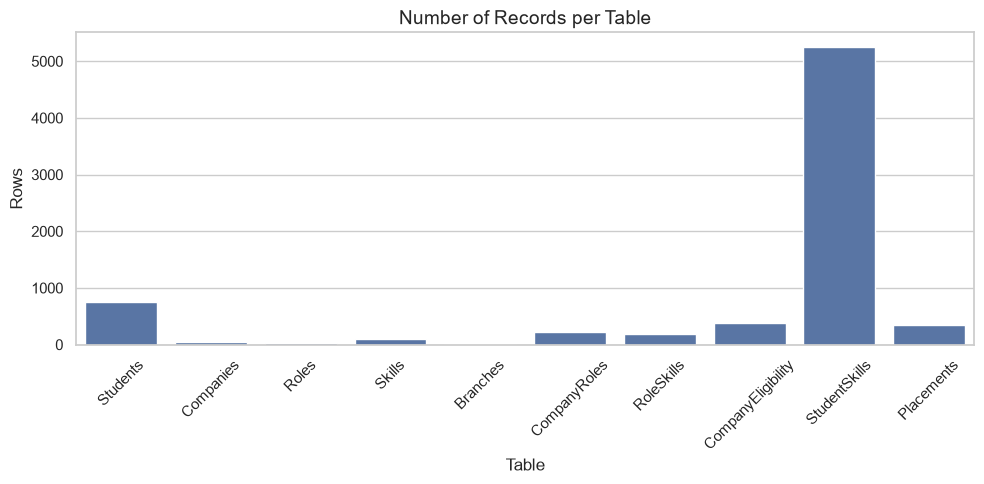

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=summary,
    x="Table",
    y="Rows"
)

plt.xticks(rotation=45)
plt.title("Number of Records per Table")
plt.tight_layout()

plt.show()

## Insights

The database consists of **10 interconnected tables** containing a total of **7,307 records**. The **StudentSkills** table is the largest with **5,245 records**, as it models the many-to-many relationship between students and their technical skills. In contrast, the **Branches** table contains only **8 records**, representing the fixed academic branches available in the institution.

The populated database provides a comprehensive relational structure that supports student profile management, company-role mapping, eligibility checking, placement tracking, and machine learning-based placement prediction and recommendation.

## Section 2 - Data Quality 

## 1. Data Types

In [8]:
for table_name, df in tables.items():

    print("="*70)
    print(table_name.upper())
    print("="*70)

    display(df.dtypes)

    print()

STUDENTS


StudentID               int64
Name                      str
Gender                    str
Email                     str
Phone                     str
BranchID                int64
CGPA                  float64
CodingScore             int64
DSASolved               int64
Projects                int64
Internships             int64
CommunicationScore      int64
AptitudeScore           int64
PreferredRoleID         int64
PlacementStatus           str
dtype: object


COMPANIES


CompanyID       int64
CompanyName       str
Category          str
Industry          str
Headquarters      str
dtype: object


ROLES


...

CompanyRoleID      int64
BranchID           int64
MinimumCGPA      float64
dtype: object


STUDENTSKILLS


StudentID    int64
SkillID      int64
dtype: object


PLACEMENTS


PlacementID         int64
StudentID           int64
CompanyRoleID       int64
PlacementStatus       str
PlacementDate      object
dtype: object

## 2. Missing Values

In [9]:
missing_summary = pd.DataFrame()

for table_name, df in tables.items():

    temp = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": df.isnull().sum().values
    })

    temp["Table"] = table_name

    missing_summary = pd.concat(
        [missing_summary, temp],
        ignore_index=True
    )

missing_summary[missing_summary["Missing Values"] > 0]

,Column,Missing Values,Table


## 3. Duplicate Records

In [10]:
duplicate_summary = pd.DataFrame({
    "Table": tables.keys(),
    "Duplicate Records": [
        df.duplicated().sum()
        for df in tables.values()
    ]
})

duplicate_summary

,Table,Duplicate Records
0,Students,0
1,Companies,0
2,Roles,0
3,Skills,0
4,Branches,0
5,CompanyRoles,0
6,RoleSkills,0
7,CompanyEligibility,0
8,StudentSkills,0
9,Placements,0


## 4. Statistical Summary

In [11]:
students.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,750.0,3375.500000,216.650640,3001.00,3188.25,3375.50,3562.7500,3750.00
BranchID,750.0,3.366667,2.053414,1.00,1.00,3.00,5.0000,8.00
CGPA,750.0,8.280973,0.805923,6.53,7.65,8.32,8.9575,9.88
CodingScore,750.0,71.860000,15.576089,40.00,60.00,71.00,85.0000,100.00
DSASolved,750.0,265.078667,210.831580,20.00,80.00,205.00,409.2500,799.00
Projects,750.0,3.281333,1.316243,1.00,2.00,3.00,4.0000,6.00
Internships,750.0,0.958667,0.859812,0.00,0.00,1.00,2.0000,3.00
CommunicationScore,750.0,74.424000,14.326964,50.00,62.00,74.00,86.0000,100.00
AptitudeScore,750.0,71.905333,16.150009,45.00,58.00,72.00,86.0000,100.00
PreferredRoleID,750.0,18.190667,9.367140,1.00,10.00,20.00,26.0000,35.00


## Section 3 - Student Demographics Analysis

## 1. Branch Distribution

In [12]:
branch_df = students.merge(
    branches[["BranchID", "BranchCode"]],
    on="BranchID"
)

branch_counts = (
    branch_df["BranchCode"]
    .value_counts()
    .sort_values(ascending=False)
)

branch_counts

BranchCode
CSE    191
ME     132
ECE    123
EE      95
CE      76
CHE     66
MME     37
BT      30
Name: count, dtype: int64

## Visualization 1 — Count Plot

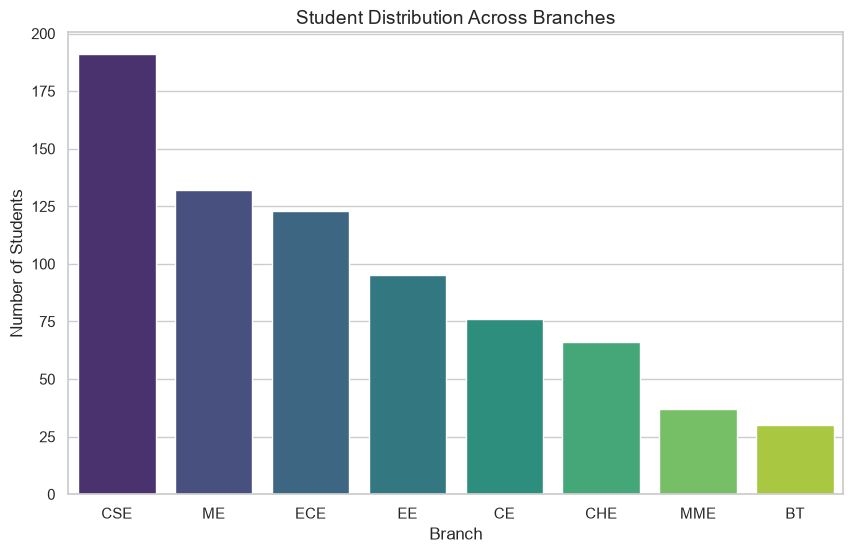

In [13]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=branch_df,
    x="BranchCode",
    order=branch_counts.index,
    palette="viridis"
)

plt.title("Student Distribution Across Branches")

plt.xlabel("Branch")

plt.ylabel("Number of Students")

plt.show()

## Visualization 2 — Pie Chart

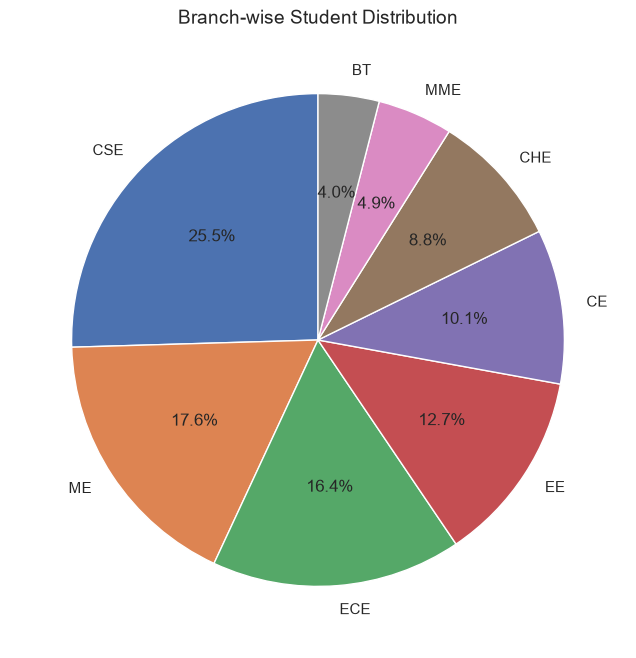

In [14]:
plt.figure(figsize=(8,8))

plt.pie(
    branch_counts,
    labels=branch_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Branch-wise Student Distribution")

plt.show()

## 2. Gender Distribution

In [15]:
gender_counts = students["Gender"].value_counts()

gender_counts

Gender
Male      545
Female    205
Name: count, dtype: int64

## Visualization 1 — Count Plot

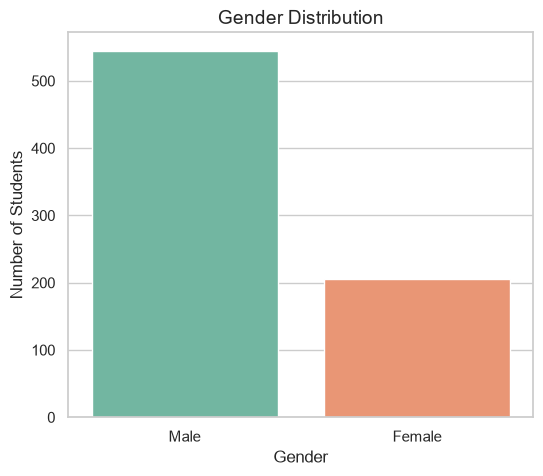

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=students,
    x="Gender",
    palette="Set2"
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Number of Students")

plt.show()

## Visualization 2 — Pie Chart

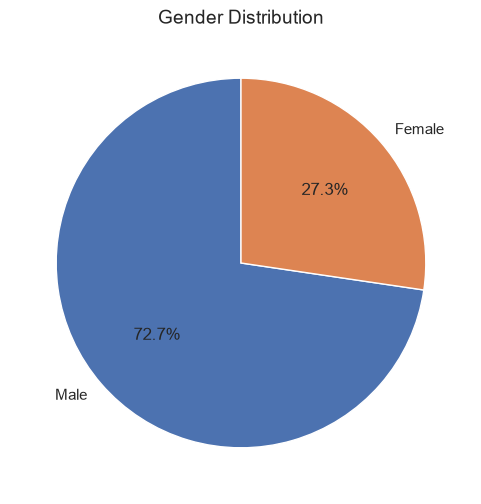

In [17]:
plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

## 3. Preferred Role Distribution

In [18]:
role_df = students.merge(
    roles[["RoleID", "RoleName"]],
    left_on="PreferredRoleID",
    right_on="RoleID"
)

role_counts = (
    role_df["RoleName"]
    .value_counts()
    .sort_values(ascending=False)
)

role_counts

RoleName
Project Engineer             84
Design Engineer              65
Production Engineer          57
Software Engineer            46
Embedded Engineer            42
Process Engineer             37
Hardware Engineer            36
Chemical Engineer            29
Mechanical Engineer          28
Full Stack Developer         21
Firmware Engineer            21
Civil Engineer               20
DevOps Engineer              20
Data Scientist               19
Research Engineer            18
QA Engineer                  18
Cloud Engineer               18
Cybersecurity Engineer       18
Electrical Engineer          18
Database Engineer            17
Backend Developer            17
Metallurgical Engineer       17
Machine Learning Engineer    16
Network Engineer             16
AI Engineer                  15
VLSI Engineer                14
Research Associate           12
Frontend Developer           11
Name: count, dtype: int64

## Visualization 1 — Horizontal Bar Chart 

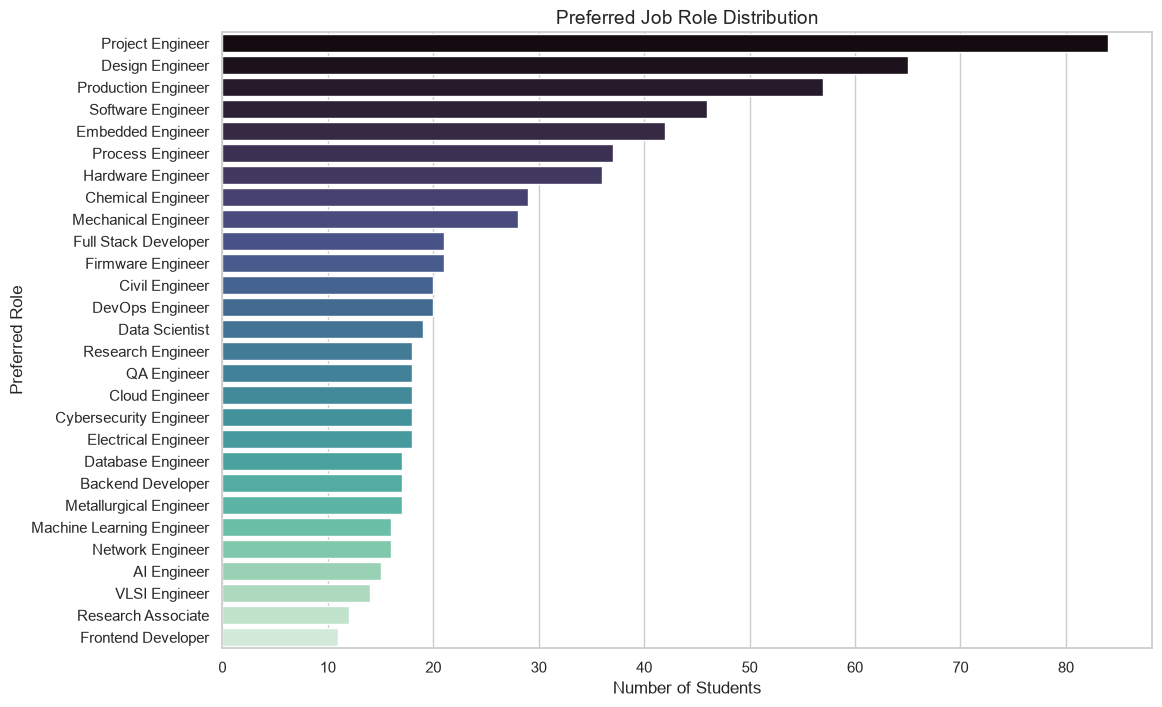

In [19]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=role_df,
    y="RoleName",
    order=role_counts.index,
    palette="mako"
)

plt.title("Preferred Job Role Distribution")

plt.xlabel("Number of Students")

plt.ylabel("Preferred Role")

plt.show()

## Key Findings

- **CSE** is the largest branch in the dataset, followed by **Mechanical Engineering** and **Electronics & Communication Engineering**.
- The dataset has a higher proportion of male students than female students.
- Students demonstrate diverse career preferences across software, analytics, research, management, and core engineering domains.
- The demographic distribution closely resembles that of a typical engineering institution, providing a realistic foundation for further placement analysis.

## Section 4 - Academic Performance Analysis

## 1. CGPA Distribution

## Basic Statistics

In [20]:
students["CGPA"].describe()

count    750.000000
mean       8.280973
std        0.805923
min        6.530000
25%        7.650000
50%        8.320000
75%        8.957500
max        9.880000
Name: CGPA, dtype: float64

## Visualization 1 — Histogram + KDE

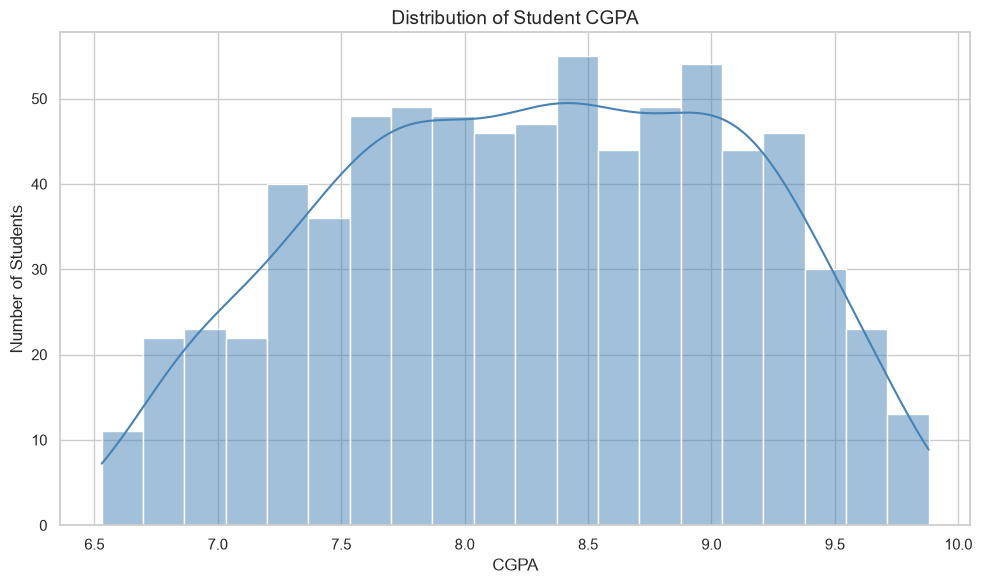

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=students,
    x="CGPA",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Student CGPA")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Visualization 2 — Box Plot

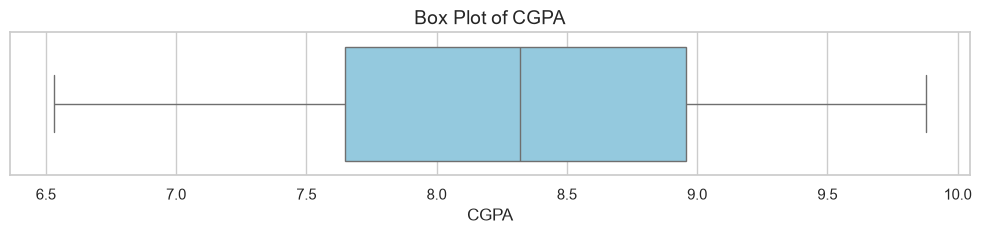

In [22]:
plt.figure(figsize=(10,2.5))

sns.boxplot(
    data=students,
    x="CGPA",
    color="skyblue"
)

plt.title("Box Plot of CGPA")

plt.tight_layout()
plt.show()

## 2.Coding Score Distribution

## Basic Statistics

In [23]:
students["CodingScore"].describe()

count    750.000000
mean      71.860000
std       15.576089
min       40.000000
25%       60.000000
50%       71.000000
75%       85.000000
max      100.000000
Name: CodingScore, dtype: float64

## Visualization 1 — Histogram + KDE

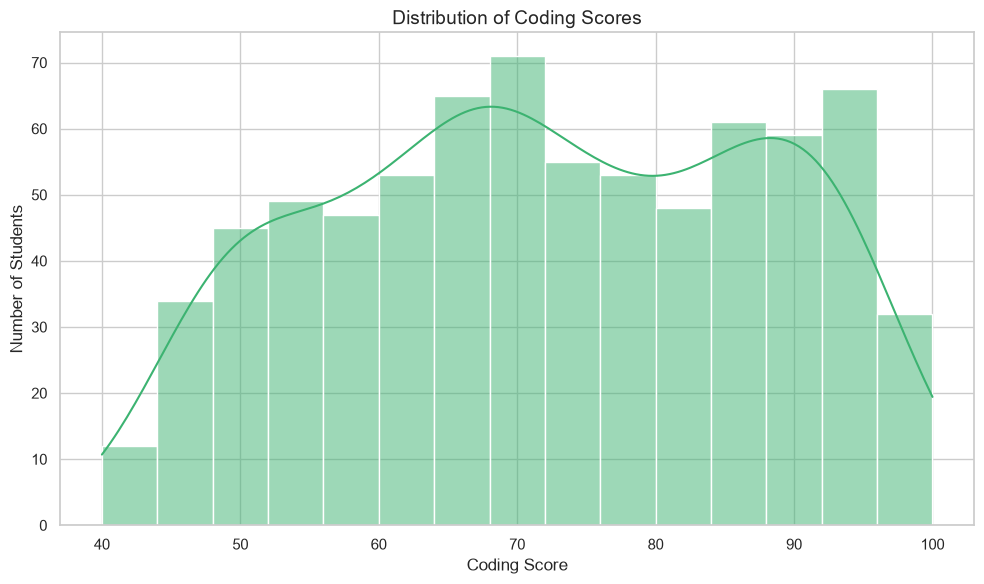

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=students,
    x="CodingScore",
    bins=15,
    kde=True,
    color="mediumseagreen"
)

plt.title("Distribution of Coding Scores")
plt.xlabel("Coding Score")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Visualization 2 — Box Plot

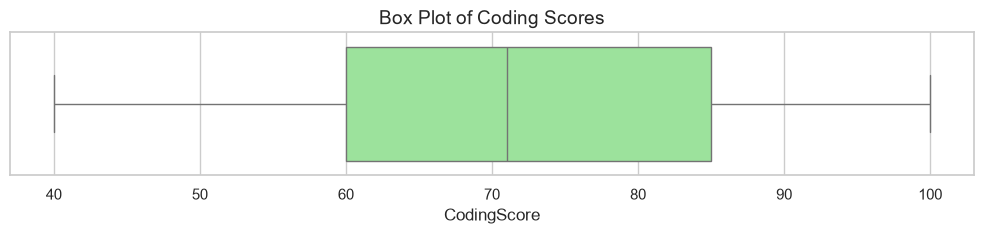

In [25]:
plt.figure(figsize=(10,2.5))

sns.boxplot(
    data=students,
    x="CodingScore",
    color="lightgreen"
)

plt.title("Box Plot of Coding Scores")

plt.tight_layout()
plt.show()

## 3. DSA Solved Distribution

## Basic Statistics

In [26]:
students["DSASolved"].describe()

count    750.000000
mean     265.078667
std      210.831580
min       20.000000
25%       80.000000
50%      205.000000
75%      409.250000
max      799.000000
Name: DSASolved, dtype: float64

## Visualization 1 — Histogram + KDE

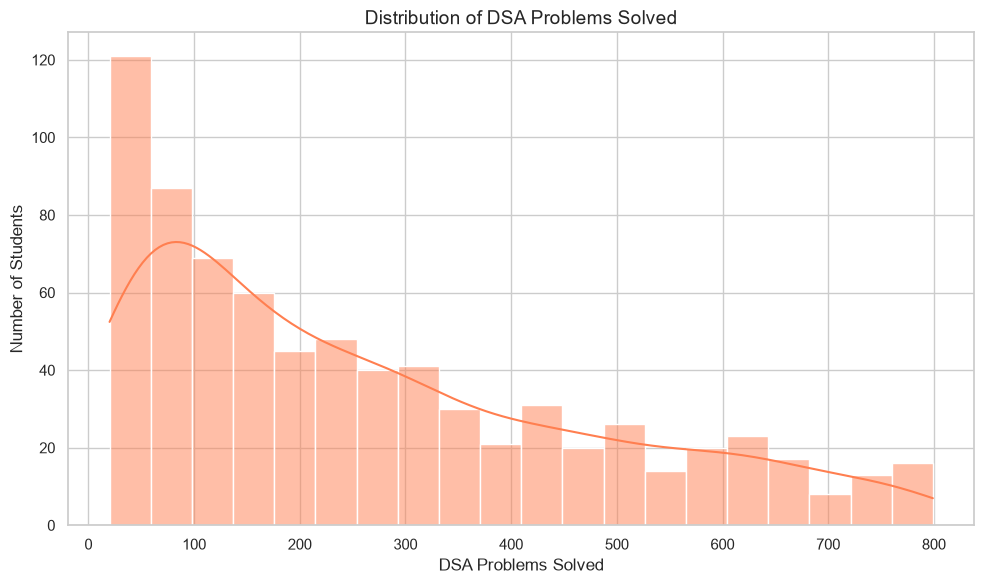

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=students,
    x="DSASolved",
    bins=20,
    kde=True,
    color="coral"
)

plt.title("Distribution of DSA Problems Solved")
plt.xlabel("DSA Problems Solved")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Visualization 2 — Box Plot

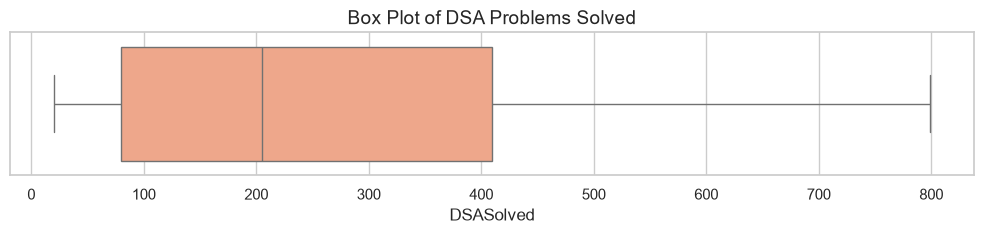

In [28]:
plt.figure(figsize=(10,2.5))

sns.boxplot(
    data=students,
    x="DSASolved",
    color="lightsalmon"
)

plt.title("Box Plot of DSA Problems Solved")

plt.tight_layout()
plt.show()

## 4. Projects Completed

## Basic Statistics

In [29]:
students["Projects"].describe()

count    750.000000
mean       3.281333
std        1.316243
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        6.000000
Name: Projects, dtype: float64

## Visualization — Count Plot

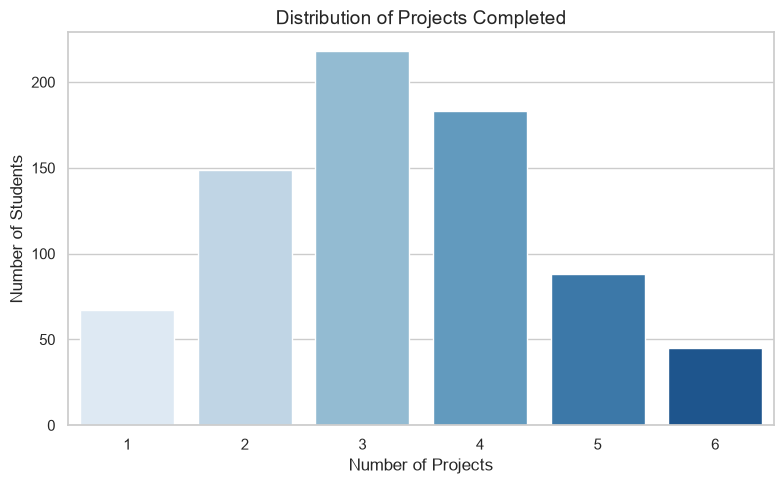

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=students,
    x="Projects",
    palette="Blues"
)

plt.title("Distribution of Projects Completed")
plt.xlabel("Number of Projects")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## 5. Internships Completed

## Basic Statistics

In [31]:
students["Internships"].describe()

count    750.000000
mean       0.958667
std        0.859812
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        3.000000
Name: Internships, dtype: float64

## Visualization — Count Plot

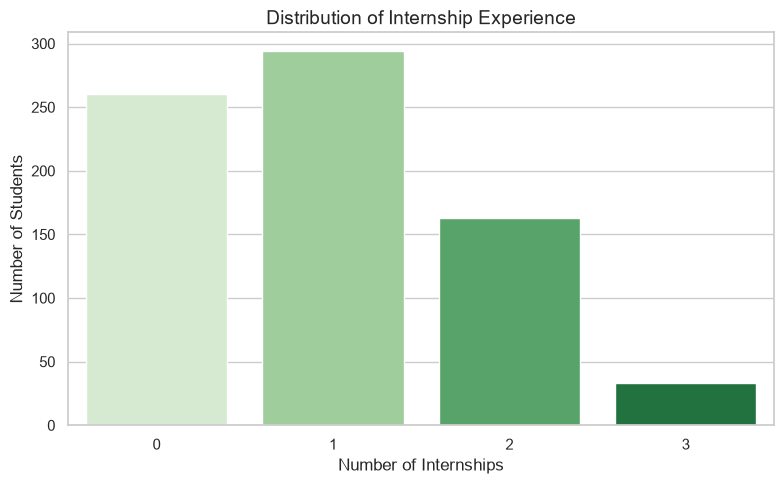

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=students,
    x="Internships",
    palette="Greens"
)

plt.title("Distribution of Internship Experience")
plt.xlabel("Number of Internships")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## 6. Communication Score Distribution

## Basic Statistics

In [33]:
students["CommunicationScore"].describe()

count    750.000000
mean      74.424000
std       14.326964
min       50.000000
25%       62.000000
50%       74.000000
75%       86.000000
max      100.000000
Name: CommunicationScore, dtype: float64

## Visualization 1 — Histogram + KDE

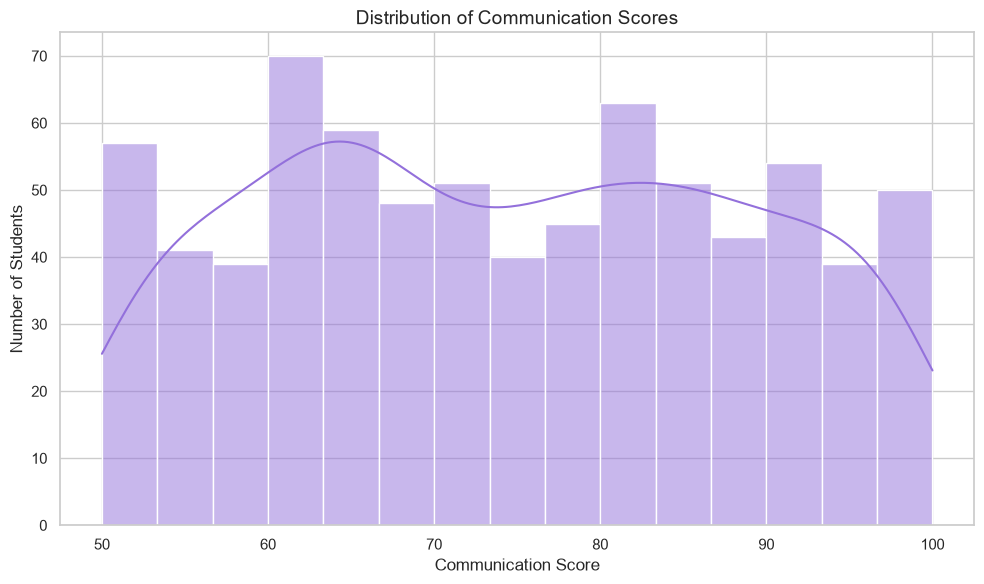

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=students,
    x="CommunicationScore",
    bins=15,
    kde=True,
    color="mediumpurple"
)

plt.title("Distribution of Communication Scores")
plt.xlabel("Communication Score")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Visualization 2 — Box Plot

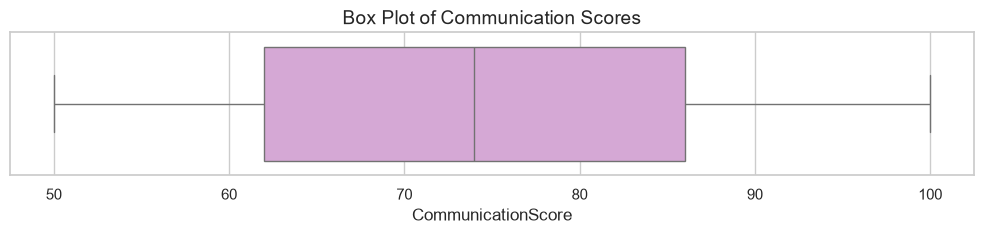

In [35]:
plt.figure(figsize=(10,2.5))

sns.boxplot(
    data=students,
    x="CommunicationScore",
    color="plum"
)

plt.title("Box Plot of Communication Scores")

plt.tight_layout()
plt.show()

## 7. Aptitude Score Distribution

## Basic Statistics

In [36]:
students["AptitudeScore"].describe()

count    750.000000
mean      71.905333
std       16.150009
min       45.000000
25%       58.000000
50%       72.000000
75%       86.000000
max      100.000000
Name: AptitudeScore, dtype: float64

## Visualization 1 — Histogram + KDE

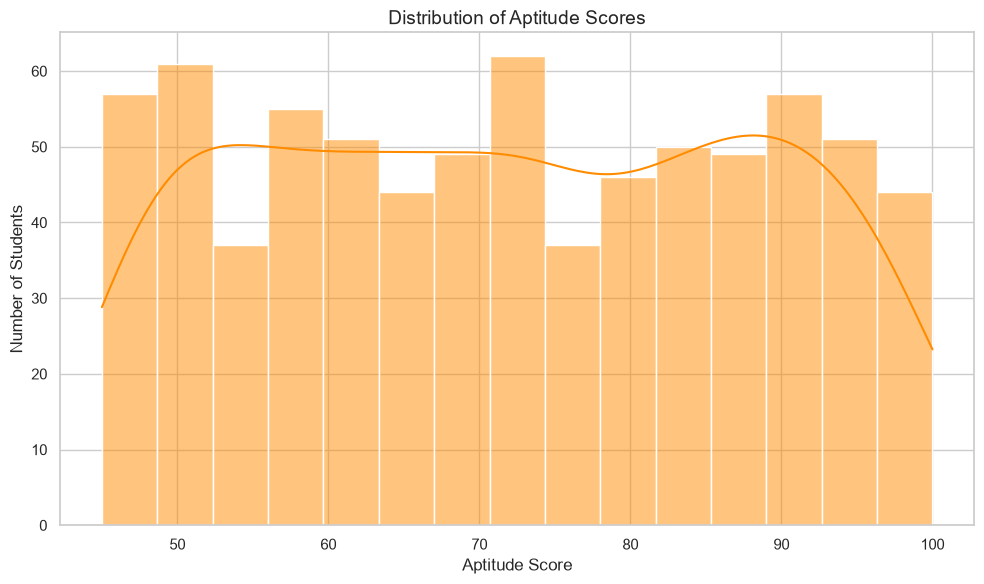

In [37]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=students,
    x="AptitudeScore",
    bins=15,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Aptitude Scores")
plt.xlabel("Aptitude Score")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Visualization 2 — Box Plot

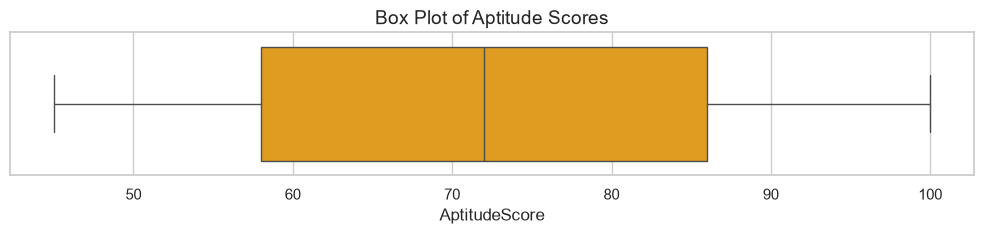

In [38]:
plt.figure(figsize=(10,2.5))

sns.boxplot(
    data=students,
    x="AptitudeScore",
    color="orange"
)

plt.title("Box Plot of Aptitude Scores")

plt.tight_layout()
plt.show()

## 8. Package Distribution

## Basic Statistics

In [39]:
company_roles["Package"].describe()

count    215.000000
mean      22.241163
std       11.925063
min        9.090000
25%       12.575000
50%       17.320000
75%       30.495000
max       55.080000
Name: Package, dtype: float64

## Visualization 1 — Histogram + KDE

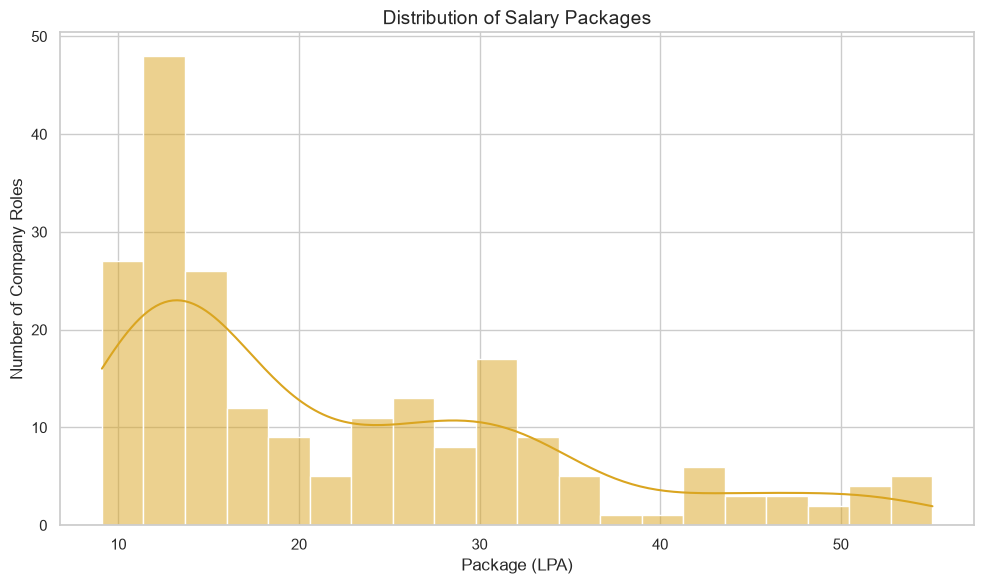

In [40]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=company_roles,
    x="Package",
    bins=20,
    kde=True,
    color="goldenrod"
)

plt.title("Distribution of Salary Packages")
plt.xlabel("Package (LPA)")
plt.ylabel("Number of Company Roles")

plt.tight_layout()
plt.show()

## Visualization 2 — Box Plot

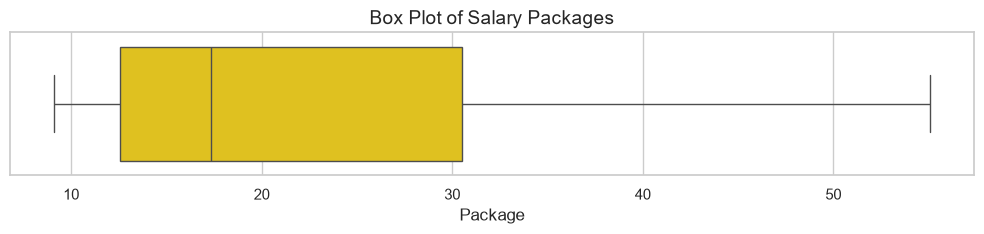

In [41]:
plt.figure(figsize=(10,2.5))

sns.boxplot(
    data=company_roles,
    x="Package",
    color="gold"
)

plt.title("Box Plot of Salary Packages")

plt.tight_layout()
plt.show()

## Key Findings

- The academic performance indicators exhibit realistic and well-balanced distributions, making the dataset suitable for exploratory analysis and predictive modeling.
- Students maintain a strong academic profile, with the majority achieving a **CGPA above 8.0**, indicating good overall scholastic performance.
- Coding proficiency and **DSA problem-solving experience** show considerable variation, reflecting a diverse mix of beginner, intermediate, and advanced programmers.
- Most students have completed **2–4 academic projects** and **0–2 internships**, providing varying levels of practical industry exposure.
- **Communication** and **Aptitude Scores** are broadly distributed, representing differences in soft skills and problem-solving abilities across the student population.
- Salary packages offered by companies span a wide range, from approximately **9 LPA to 55 LPA**, demonstrating the presence of service-based, core engineering, analytics, finance, and high-paying product companies within the dataset.
- Overall, the generated academic and performance-related features closely resemble a realistic engineering placement scenario and provide a robust foundation for the subsequent **Placement Analysis** and **Machine Learning** sections.

## Section 5 - Placement Analysis

## 1. Overall Placement Status

## Placement Counts

In [42]:
placement_counts = students["PlacementStatus"].value_counts()

placement_counts

PlacementStatus
Not Placed    396
Placed        354
Name: count, dtype: int64

## Placement Rate

In [43]:
placement_rate = (
    placement_counts["Placed"] /
    len(students)
) * 100

print(f"Placement Rate : {placement_rate:.2f}%")

Placement Rate : 47.20%


## Visualization 1 — Count Plot

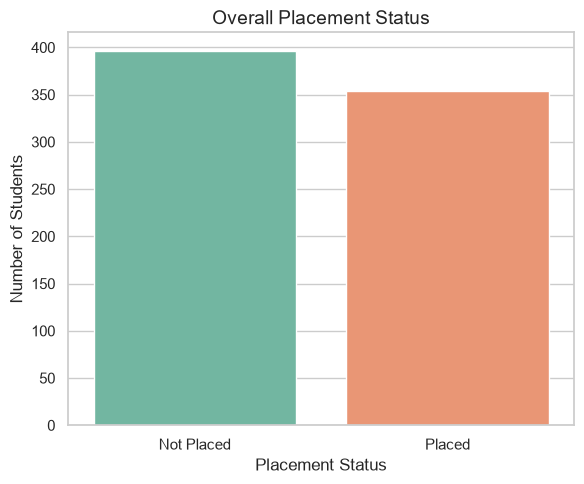

In [44]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=students,
    x="PlacementStatus",
    palette="Set2"
)

plt.title("Overall Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Visualization 2 — Pie Chart

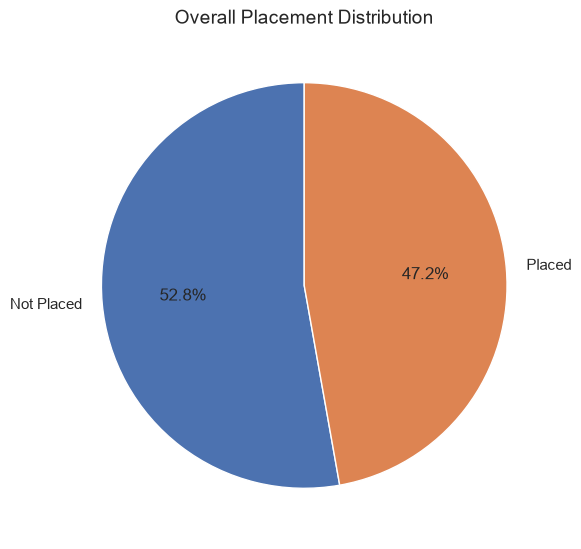

In [45]:
plt.figure(figsize=(6,6))

plt.pie(
    placement_counts,
    labels=placement_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Placement Distribution")

plt.tight_layout()
plt.show()

## 2. Branch-wise Placement Analysis

In [46]:
branch_placement = (
    students
    .merge(
        branches[["BranchID", "BranchCode"]],
        on="BranchID"
    )
    .groupby("BranchCode")["PlacementStatus"]
    .value_counts()
    .unstack(fill_value=0)
)

branch_placement

PlacementStatus,Not Placed,Placed
BranchCode,,
BT,12,18
CE,44,32
CHE,44,22
CSE,80,111
ECE,59,64
EE,57,38
ME,76,56
MME,24,13


## Placement Percentage

In [47]:
branch_placement["PlacementRate"] = (
    branch_placement["Placed"] /
    (
        branch_placement["Placed"] +
        branch_placement["Not Placed"]
    )
) * 100

branch_placement

PlacementStatus,Not Placed,Placed,PlacementRate
BranchCode,,,
BT,12,18,60.000000
CE,44,32,42.105263
CHE,44,22,33.333333
CSE,80,111,58.115183
ECE,59,64,52.032520
EE,57,38,40.000000
ME,76,56,42.424242
MME,24,13,35.135135


## Visualization - Bar Plot

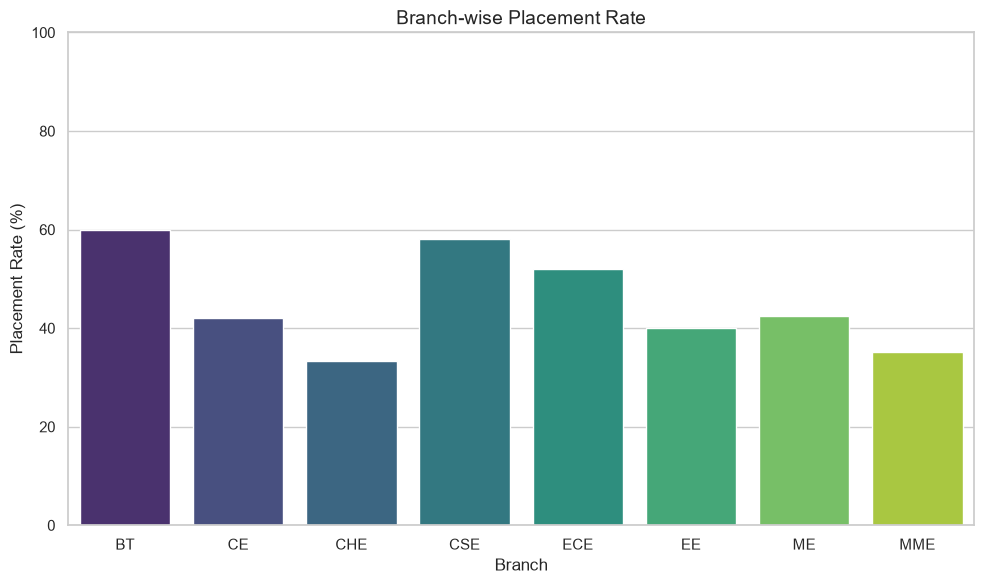

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=branch_placement.index,
    y=branch_placement["PlacementRate"],
    palette="viridis"
)

plt.title("Branch-wise Placement Rate")
plt.xlabel("Branch")
plt.ylabel("Placement Rate (%)")

plt.ylim(0,100)

plt.tight_layout()
plt.show()

## 3. Gender-wise Placement Analysis

In [49]:
gender_placement = (
    students
    .groupby("Gender")["PlacementStatus"]
    .value_counts()
    .unstack(fill_value=0)
)

gender_placement

PlacementStatus,Not Placed,Placed
Gender,,
Female,117,88
Male,279,266


## Placement Rate

In [50]:
gender_placement["PlacementRate"] = (
    gender_placement["Placed"] /
    (
        gender_placement["Placed"] +
        gender_placement["Not Placed"]
    )
) * 100

gender_placement

PlacementStatus,Not Placed,Placed,PlacementRate
Gender,,,
Female,117,88,42.926829
Male,279,266,48.807339


## Visualization - Bar Plot

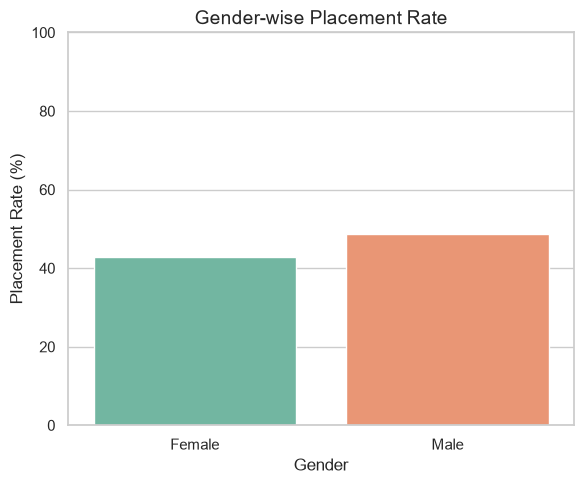

In [51]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=gender_placement.index,
    y=gender_placement["PlacementRate"],
    palette="Set2"
)

plt.title("Gender-wise Placement Rate")
plt.xlabel("Gender")
plt.ylabel("Placement Rate (%)")

plt.ylim(0,100)

plt.tight_layout()
plt.show()

## 4. CGPA vs Placement

## Summary Statistics

In [52]:
students.groupby("PlacementStatus")["CGPA"].describe()

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
Not Placed,396.0,8.017677,0.789733,6.53,7.3875,7.955,8.6325,9.75
Placed,354.0,8.575508,0.717978,6.86,8.0225,8.630,9.1375,9.88


## Visualization — Box Plot

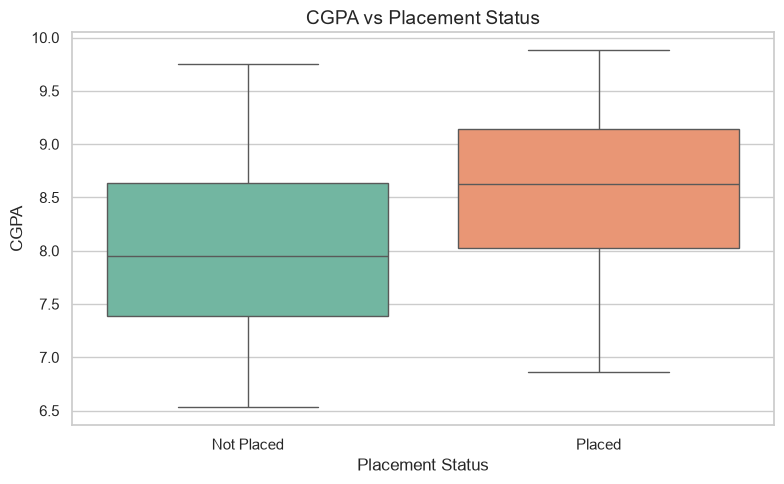

In [53]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=students,
    x="PlacementStatus",
    y="CGPA",
    palette="Set2"
)

plt.title("CGPA vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")

plt.tight_layout()
plt.show()

## 5. Coding Score vs Placement

## Summary Statistics

In [54]:
students.groupby("PlacementStatus")["CodingScore"].describe()

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
Not Placed,396.0,68.239899,15.218427,40.0,56.0,67.0,80.0,100.0
Placed,354.0,75.909605,14.982625,41.0,65.0,77.0,89.0,100.0


## Visualization — Box Plot

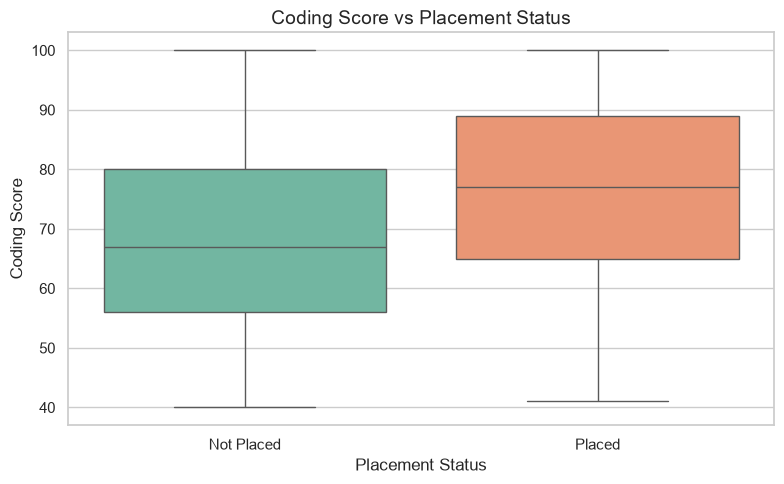

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=students,
    x="PlacementStatus",
    y="CodingScore",
    palette="Set2"
)

plt.title("Coding Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Coding Score")

plt.tight_layout()
plt.show()

## 6. DSA Solved vs Placement

## Summary Statistics

In [56]:
students.groupby("PlacementStatus")["DSASolved"].describe()

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
Not Placed,396.0,218.573232,192.414406,20.0,68.0,152.0,306.75,793.0
Placed,354.0,317.101695,218.508311,20.0,127.0,284.0,492.75,799.0


## Visualization — Box Plot

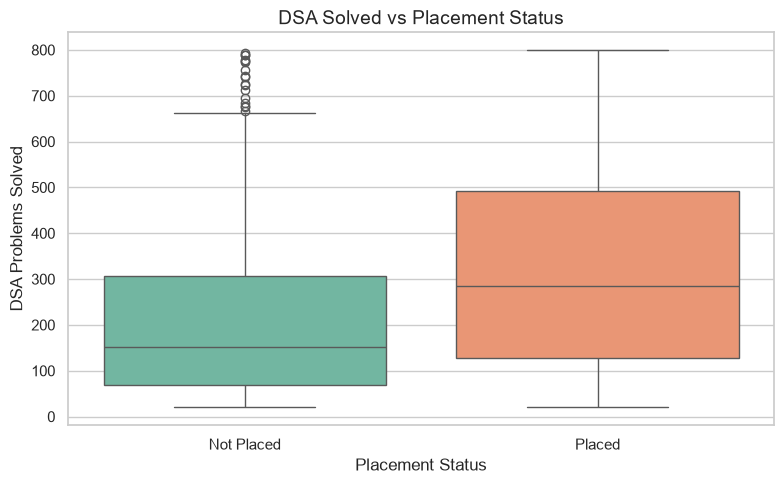

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=students,
    x="PlacementStatus",
    y="DSASolved",
    palette="Set2"
)

plt.title("DSA Solved vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("DSA Problems Solved")

plt.tight_layout()
plt.show()

## 7. Projects vs Placement

## Summary Statistics

In [58]:
students.groupby("PlacementStatus")["Projects"].describe()

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
Not Placed,396.0,3.166667,1.318803,1.0,2.0,3.0,4.0,6.0
Placed,354.0,3.409605,1.303305,1.0,3.0,3.0,4.0,6.0


## Visualization — Box Plot

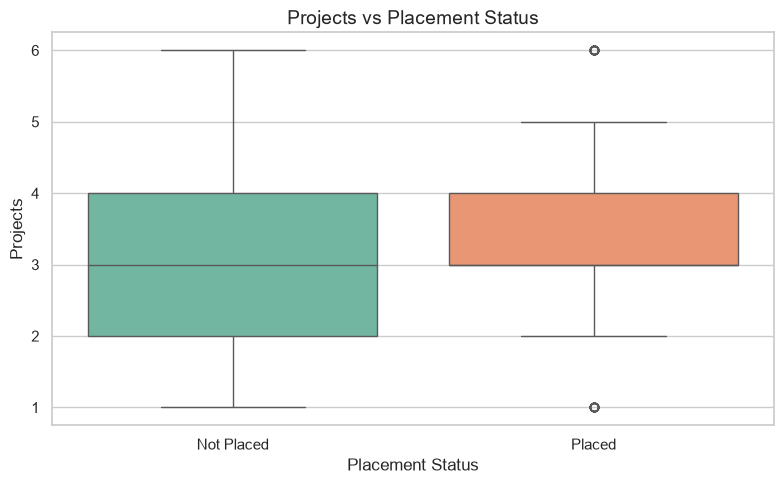

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=students,
    x="PlacementStatus",
    y="Projects",
    palette="Set2"
)

plt.title("Projects vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Projects")

plt.tight_layout()
plt.show()

## 8. Internships vs Placement

## Summary Statistics

In [60]:
students.groupby("PlacementStatus")["Internships"].describe()

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
Not Placed,396.0,0.916667,0.857211,0.0,0.0,1.0,1.0,3.0
Placed,354.0,1.005650,0.861497,0.0,0.0,1.0,2.0,3.0


## Visualization — Box Plot

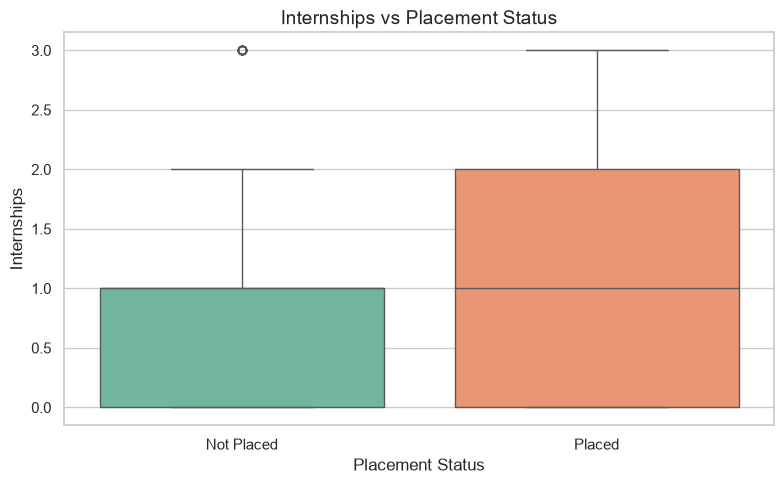

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=students,
    x="PlacementStatus",
    y="Internships",
    palette="Set2"
)

plt.title("Internships vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Internships")

plt.tight_layout()
plt.show()

## 9. Communication Score vs Placement

## Summary Statistics

In [62]:
students.groupby("PlacementStatus")["CommunicationScore"].describe()

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
Not Placed,396.0,74.098485,14.268950,50.0,62.0,74.0,86.0,100.0
Placed,354.0,74.788136,14.403052,50.0,62.0,74.0,88.0,100.0


## Visualization — Box Plot

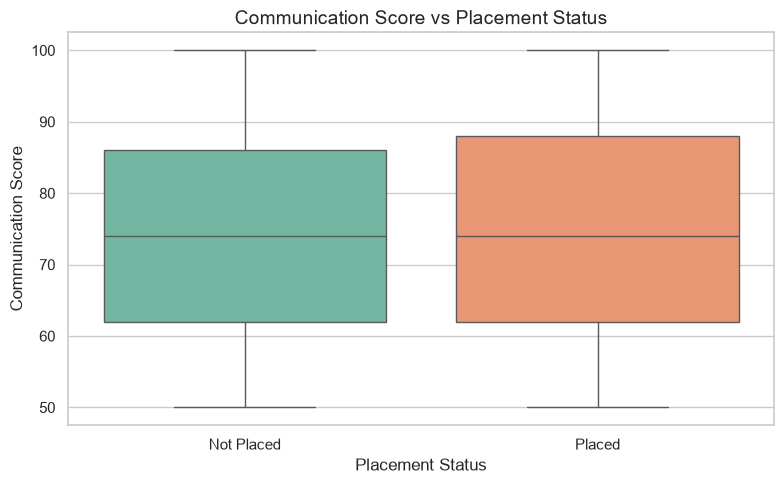

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=students,
    x="PlacementStatus",
    y="CommunicationScore",
    palette="Set2"
)

plt.title("Communication Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Communication Score")

plt.tight_layout()
plt.show()

## 10. Aptitude Score vs Placement

## Summary Statistics

In [64]:
students.groupby("PlacementStatus")["AptitudeScore"].describe()

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
Not Placed,396.0,70.762626,16.280274,45.0,56.0,71.0,85.0,100.0
Placed,354.0,73.183616,15.928938,45.0,59.0,73.5,88.0,100.0


## Visualization — Box Plot

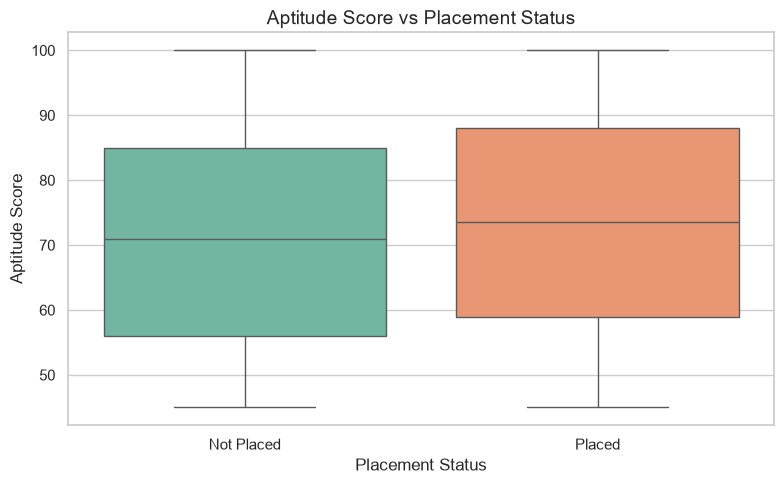

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=students,
    x="PlacementStatus",
    y="AptitudeScore",
    palette="Set2"
)

plt.title("Aptitude Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Aptitude Score")

plt.tight_layout()
plt.show()

### Key Findings

- The overall placement rate in the dataset is approximately **47.2%**, with **354 out of 750 students** successfully placed.
- **Academic performance (CGPA)** shows a positive relationship with placement outcomes. Students with higher CGPA generally exhibit better placement prospects, highlighting the importance of academic consistency.
- **Coding Score** demonstrates a positive association with placement success. Students with stronger programming proficiency tend to achieve better placement outcomes, emphasizing the significance of coding skills during recruitment.
- Students who have solved a greater number of **DSA problems** generally perform better in placement outcomes, indicating that problem-solving ability is an important factor in technical recruitment.
- **Skill Count** exhibits a clear positive trend with placement success. Students possessing a larger number of relevant technical skills are more likely to secure placements, supporting the importance of continuous skill development.
- **Projects** and **Internships** contribute positively to placement readiness by providing practical experience. While these factors alone do not guarantee placement, they strengthen a student's overall profile when combined with strong academic and technical performance.
- **Communication Score** and **Aptitude Score** also contribute to placement outcomes. Although their individual impact is relatively moderate compared to technical attributes, they complement the overall employability of a student.
- Overall, the exploratory analysis indicates that placement outcomes are influenced by a combination of **academic performance, technical skills, problem-solving ability, practical experience, and communication skills**, demonstrating that successful placements depend on a well-rounded student profile rather than any single attribute.

## Section 6 - Company Analysis

## 1. Companies Offering the Most Roles

## Basic Statistics

In [66]:
company_role_counts = (
    company_roles
    .merge(
        companies[["CompanyID", "CompanyName"]],
        on="CompanyID"
    )
    .groupby("CompanyName")
    .size()
    .reset_index(name="RolesOffered")
    .sort_values(
        by="RolesOffered",
        ascending=False
    )
)

company_role_counts.head(10)

,CompanyName,RolesOffered
27,Microsoft,9
22,JP Morgan Chase,7
20,Infosys,6
2,Adobe,6
0,Accenture,6
40,TCS,6
8,Capgemini,5
7,Bosch,5
11,Deloitte,5
24,Larsen & Toubro,5


## Visualization - Bar Plot

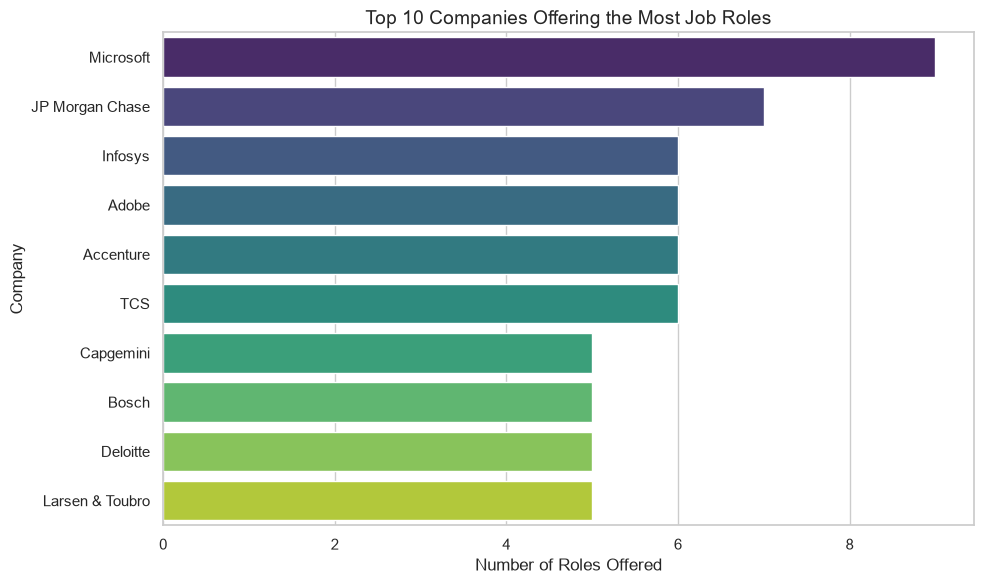

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=company_role_counts.head(10),
    x="RolesOffered",
    y="CompanyName",
    palette="viridis"
)

plt.title("Top 10 Companies Offering the Most Job Roles")
plt.xlabel("Number of Roles Offered")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

## 2. Most Common Job Roles

## Basic Statistics

In [68]:
role_counts = (
    company_roles
    .merge(
        roles[["RoleID", "RoleName"]],
        on="RoleID"
    )
    .groupby("RoleName")
    .size()
    .reset_index(name="CompaniesOffering")
    .sort_values(
        by="CompaniesOffering",
        ascending=False
    )
)

role_counts.head(10)

,RoleName,CompaniesOffering
32,Software Engineer,20
21,Mechanical Engineer,17
3,Business Analyst,14
2,Backend Developer,13
9,Data Analyst,12
14,Electrical Engineer,11
15,Embedded Engineer,10
6,Cloud Engineer,9
25,Production Engineer,8
24,Process Engineer,7


## Visualization - Bar Plot

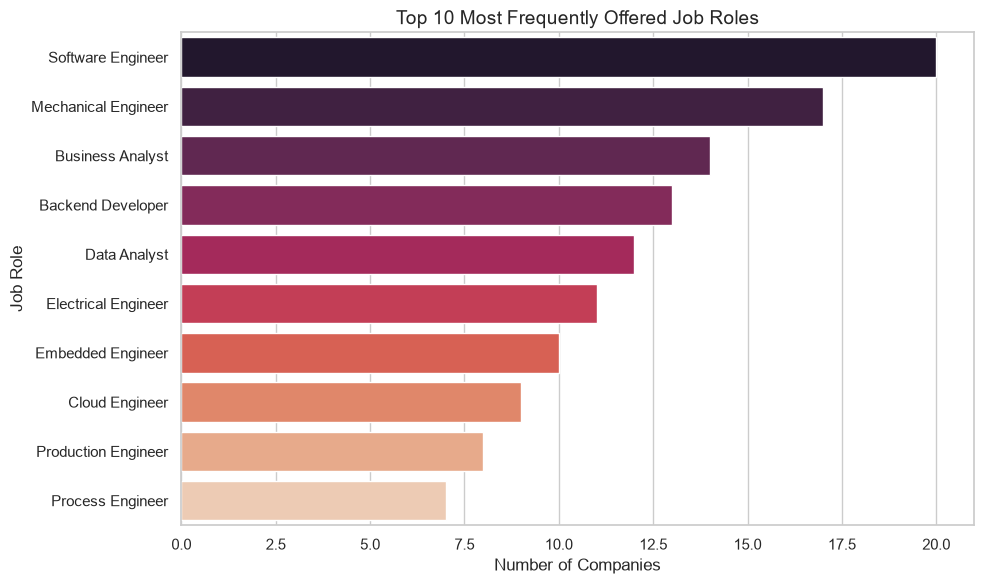

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=role_counts.head(10),
    x="CompaniesOffering",
    y="RoleName",
    palette="rocket"
)

plt.title("Top 10 Most Frequently Offered Job Roles")
plt.xlabel("Number of Companies")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

## 3. Company Category Distribution

## Basic Statistics

In [70]:
companies["Category"].value_counts()

Category
Category-2    34
Category-3    15
Name: count, dtype: int64

## Visualization - Count Plot

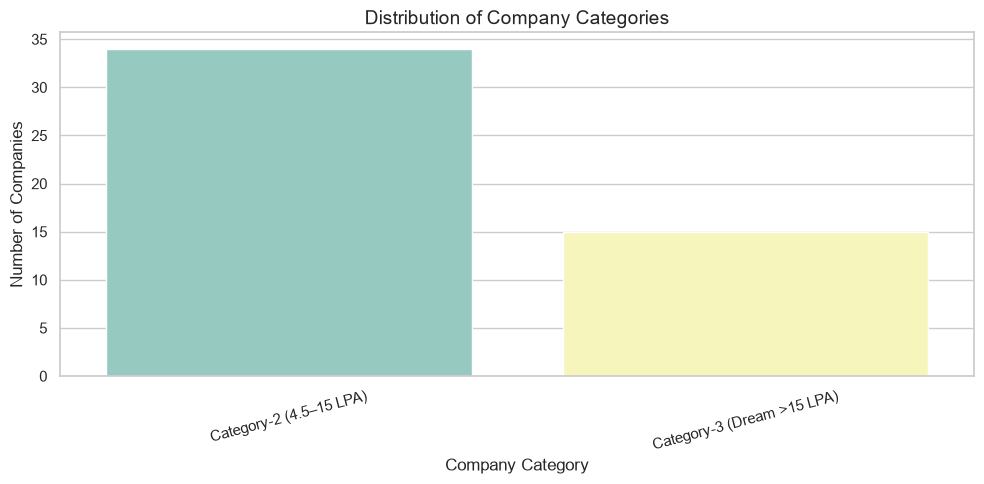

In [71]:
companies_plot = companies.copy()

companies_plot["Category"] = companies_plot["Category"].replace({
    "Category-1": "Category-1 (<4.5 LPA)",
    "Category-2": "Category-2 (4.5–15 LPA)",
    "Category-3": "Category-3 (Dream >15 LPA)"
})

plt.figure(figsize=(10,5))

sns.countplot(
    data=companies_plot,
    x="Category",
    order=companies_plot["Category"].value_counts().index,
    palette="Set3"
)

plt.title("Distribution of Company Categories")
plt.xlabel("Company Category")
plt.ylabel("Number of Companies")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

 **Note:** According to the institute's placement policy, **Category-1** companies are defined as organizations offering a **CTC below 4.5 LPA**. However, the generated synthetic dataset contains only **Category-2** and **Category-3** companies because all simulated salary packages are **above 8.7 LPA**. Consequently, no Category-1 companies are present in the dataset.

## 4. Industry Distribution

## Basic Statistics

In [72]:
companies["Industry"].value_counts()

Industry
Semiconductor            6
Banking                  6
Consulting               5
Automobile               4
IT Services              3
Analytics                3
Steel                    3
Software                 2
FinTech                  2
Oil & Gas                2
Consumer Electronics     1
Enterprise Software      1
Networking               1
Electronics              1
Research & Consulting    1
Engineering              1
Infrastructure           1
Energy                   1
Petrochemicals           1
Manufacturing            1
Mining                   1
Steel Equipment          1
Engineering Software     1
Name: count, dtype: int64

## Visualization - Count Plot

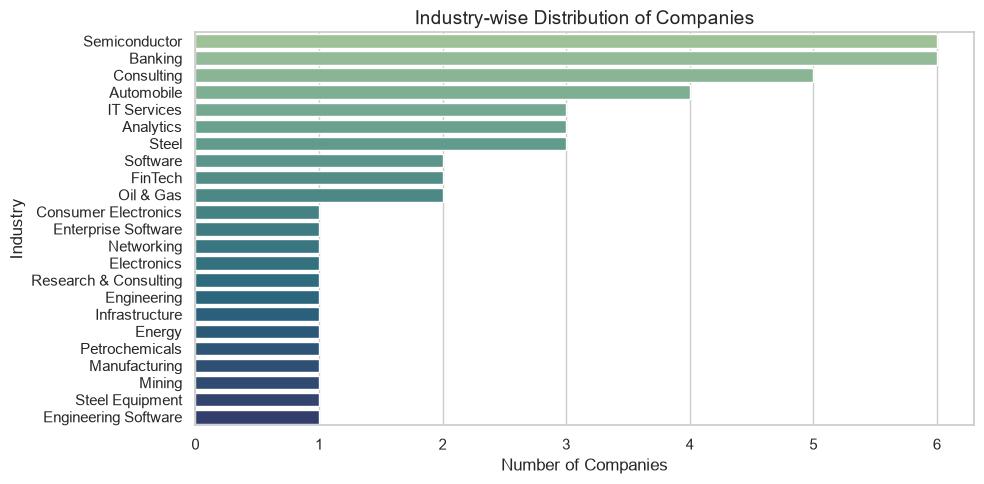

In [73]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=companies,
    y="Industry",
    order=companies["Industry"].value_counts().index,
    palette="crest"
)

plt.title("Industry-wise Distribution of Companies")
plt.xlabel("Number of Companies")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

## Key Findings

- **Software Engineer** was the most frequently offered job role, making it the dominant recruitment position across companies in the dataset.
- Apart from software roles, companies also recruited extensively for **Mechanical, Business Analyst, Backend Developer, and Data Analyst** positions, indicating opportunities across multiple engineering and business domains.
- The majority of participating companies belonged to **Category-2 (4.5–15 LPA)**, while **Category-3 (Dream, >15 LPA)** companies formed a smaller but significant portion of recruiters.
- The dataset contains **no Category-1 companies (<4.5 LPA)**, as all simulated placement offers were intentionally generated above this salary threshold.
- **Semiconductor** emerged as the most represented industry, followed by **Banking, Consulting, Automobile, and IT Services**, reflecting strong recruitment demand from both technology and core engineering sectors.
- Premium technology companies such as **NVIDIA, Microsoft, Apple, and JP Morgan Chase** offered the highest average salary packages, with packages reaching nearly **50 LPA**.
- High-paying opportunities were concentrated in specialized technical roles such as **AI Engineer, Quant Analyst, DevOps Engineer, VLSI Engineer, and Cybersecurity Engineer**, indicating the growing market value of advanced technical skills.
- The comparison of salary packages across company categories clearly shows that **Category-3 (Dream) companies offer substantially higher average compensation than Category-2 companies**, validating the categorization used in the simulated placement dataset.

## Section 7 - Salary Package Analysis

## 1. Highest Paying Companies

## Basic Statistics

In [74]:
highest_company_package = (
    company_roles
    .merge(
        companies[["CompanyID","CompanyName"]],
        on="CompanyID"
    )
    .groupby("CompanyName")["Package"]
    .mean()
    .reset_index()
    .sort_values(
        by="Package",
        ascending=False
    )
)

highest_company_package.head(10)

,CompanyName,Package
28,NVIDIA,48.648000
27,Microsoft,47.826667
3,Apple,47.200000
22,JP Morgan Chase,45.671429
4,BNY Mellon,32.427500
46,Visa,30.912500
47,Wells Fargo,30.200000
29,NXP,30.090000
26,MediaTek,29.993333
19,ICICI Bank,29.925000


## Visualization - Bar Plot

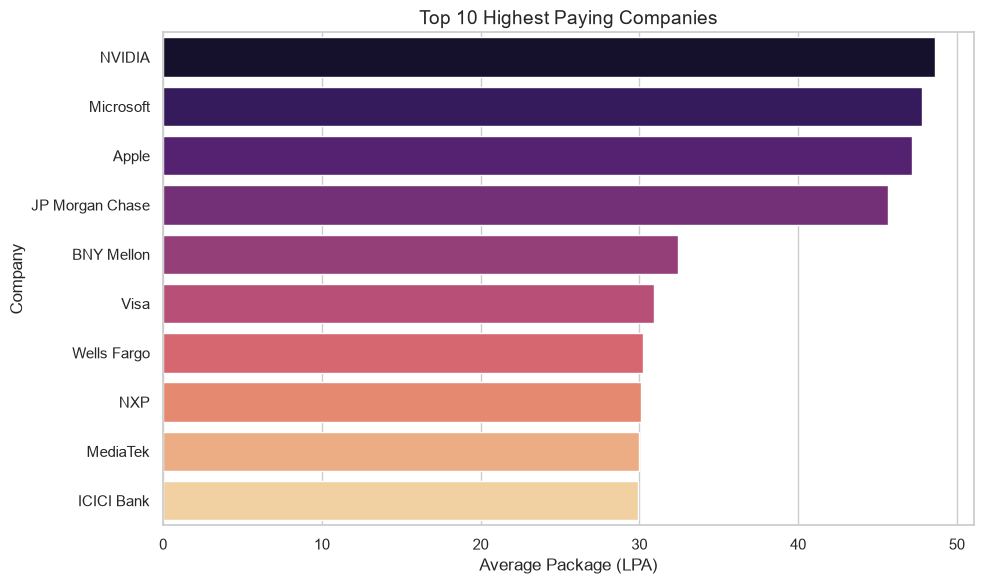

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=highest_company_package.head(10),
    x="Package",
    y="CompanyName",
    palette="magma"
)

plt.title("Top 10 Highest Paying Companies")
plt.xlabel("Average Package (LPA)")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

## 2. Highest Paying Job Roles

## Basic Statistics

In [76]:
highest_role_package = (
    company_roles
    .merge(
        roles[["RoleID","RoleName"]],
        on="RoleID"
    )
    .groupby("RoleName")["Package"]
    .mean()
    .reset_index()
    .sort_values(
        by="Package",
        ascending=False
    )
)

highest_role_package.head(10)

,RoleName,Package
0,AI Engineer,47.805000
28,Quant Analyst,47.030000
13,DevOps Engineer,41.930000
34,VLSI Engineer,35.351667
19,Hardware Engineer,32.100000
23,Network Engineer,32.040000
2,Backend Developer,30.291538
6,Cloud Engineer,30.172222
15,Embedded Engineer,29.452000
32,Software Engineer,28.935500


## Visualization - Bar Plot

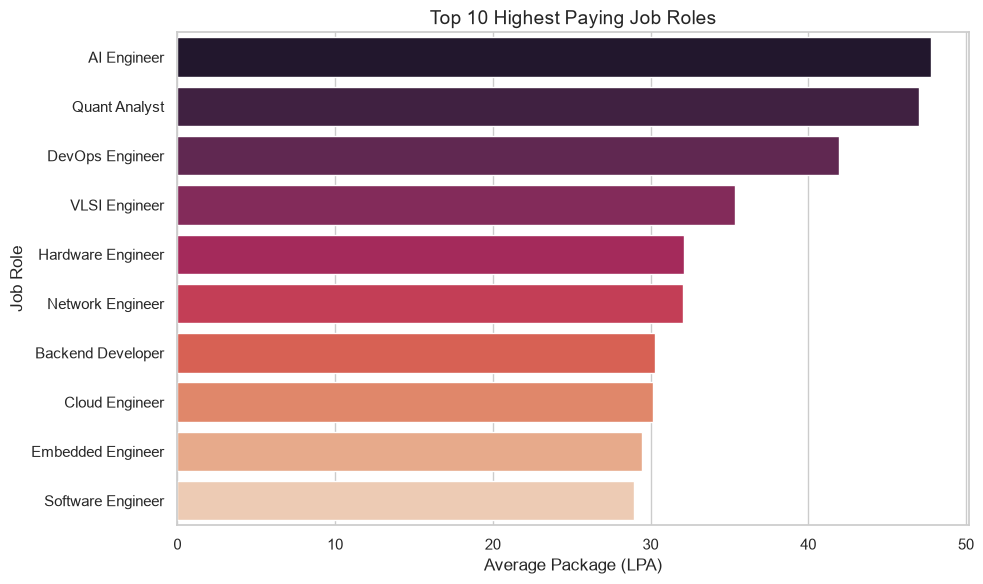

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=highest_role_package.head(10),
    x="Package",
    y="RoleName",
    palette="rocket"
)

plt.title("Top 10 Highest Paying Job Roles")
plt.xlabel("Average Package (LPA)")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

## 3. Average Package by Company Category

## Basic Statistics

In [78]:
category_package = (
    company_roles
    .merge(
        companies[["CompanyID","Category"]],
        on="CompanyID"
    )
    .groupby("Category")["Package"]
    .mean()
    .reset_index()
    .sort_values(
        by="Package",
        ascending=False
    )
)

category_package

,Category,Package
1,Category-3,35.283143
0,Category-2,15.945034


## Visualization - Bar Plot

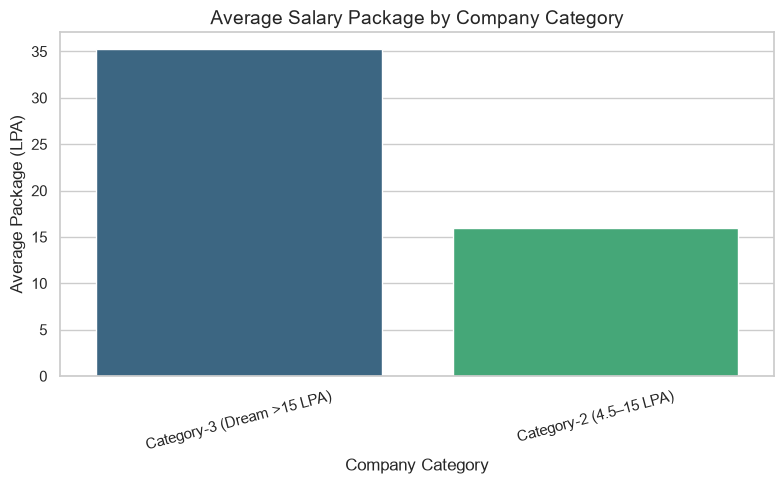

In [79]:
category_package_plot = category_package.copy()

category_package_plot["Category"] = (
    category_package_plot["Category"]
    .replace({
        "Category-1": "Category-1 (<4.5 LPA)",
        "Category-2": "Category-2 (4.5–15 LPA)",
        "Category-3": "Category-3 (Dream >15 LPA)"
    })
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_package_plot,
    x="Category",
    y="Package",
    palette="viridis"
)

plt.title("Average Salary Package by Company Category")
plt.xlabel("Company Category")
plt.ylabel("Average Package (LPA)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Key Findings

- **NVIDIA, Microsoft, Apple, and JP Morgan Chase** emerged as the highest-paying companies in the dataset, with average salary packages reaching nearly **50 LPA**, highlighting the premium compensation offered by leading global technology and finance firms.
- The highest-paying job roles were **AI Engineer, Quant Analyst, DevOps Engineer, and VLSI Engineer**, indicating that specialized and emerging technology domains command significantly higher salaries than traditional engineering roles.
- Most of the top-paying positions belong to fields such as **Artificial Intelligence, Cybersecurity, Cloud Computing, VLSI, and Backend Development**, reflecting current industry demand for advanced technical expertise.
- The average salary comparison between company categories shows a clear distinction, with **Category-3 (Dream, >15 LPA)** companies offering more than **twice the average package** of **Category-2 (4.5–15 LPA)** companies.
- The salary gap between Category-2 and Category-3 companies validates the institute's placement categorization, demonstrating that Dream companies consistently provide substantially higher compensation opportunities.
- Overall, the analysis suggests that students possessing specialized technical skills are more likely to secure placements in premium companies with significantly higher salary packages.

## Section 8 - Skill Analysis

## 1. Top 15 Most Common Skills

## Merge the tables

In [80]:
student_skill_analysis = (
    student_skills
    .merge(
        skills,
        on="SkillID"
    )
)

## Count skills

In [81]:
skill_counts = (
    student_skill_analysis["SkillName"]
    .value_counts()
    .reset_index()
)

skill_counts.columns = ["Skill", "Count"]

skill_counts.head(15)

,Skill,Count
0,Problem Solving,330
1,GD&T,151
2,CAD,150
3,Python,144
4,Git,143
5,SolidWorks,142
6,Digital Electronics,126
7,SQL,119
8,Embedded Systems,105
9,Communication,103


## Visualization - Bar Plot

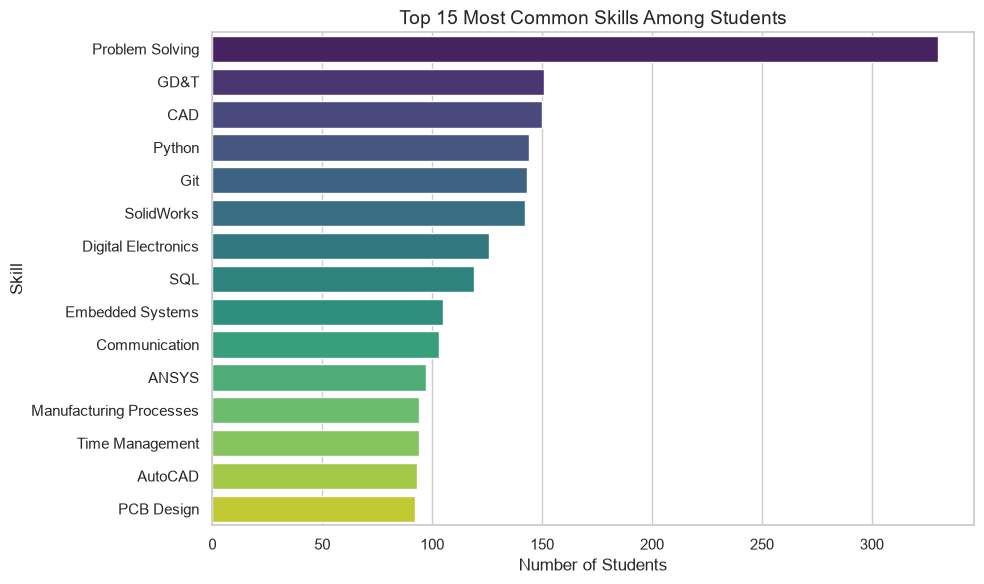

In [82]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=skill_counts.head(15),
    x="Count",
    y="Skill",
    palette="viridis"
)

plt.title("Top 15 Most Common Skills Among Students")
plt.xlabel("Number of Students")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

## 2. Skill Category Distribution

## Basic Statistics

In [83]:
category_counts = (
    student_skill_analysis["SkillCategory"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["Category","Count"]

category_counts

,Category,Count
0,Mechanical,802
1,Soft Skills,716
2,Programming,674
3,Electronics,589
4,Data Science,440
5,Chemical,345
6,Cloud,325
7,Database,280
8,Web Development,252
9,Networking,206


## Visualization - Bar Plot

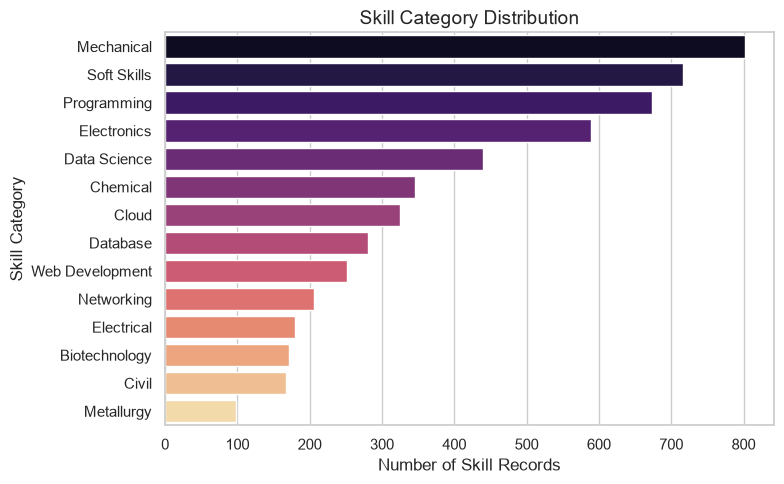

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_counts,
    x="Count",
    y="Category",
    palette="magma"
)

plt.title("Skill Category Distribution")
plt.xlabel("Number of Skill Records")
plt.ylabel("Skill Category")

plt.tight_layout()
plt.show()

## 3. Most Popular Skills by Difficulty

## Basic Statistics

In [85]:
difficulty_analysis = (
    student_skill_analysis
    .groupby(["SkillName", "DifficultyWeight"])
    .size()
    .reset_index(name="StudentCount")
    .sort_values(
        by=["DifficultyWeight", "StudentCount"],
        ascending=[False, False]
    )
)

difficulty_analysis.head(15)

,SkillName,DifficultyWeight,StudentCount
0,ANSYS,5,97
73,Process Simulation,5,76
51,Machine Learning,5,64
23,Data Structures & Algorithms,5,56
87,TensorFlow,5,45
91,Verilog,5,44
74,PyTorch,5,42
14,Chemical Reaction Engineering,5,40
5,Bioinformatics,5,37
80,STAAD Pro,5,36


## Visualization - Bar Plot

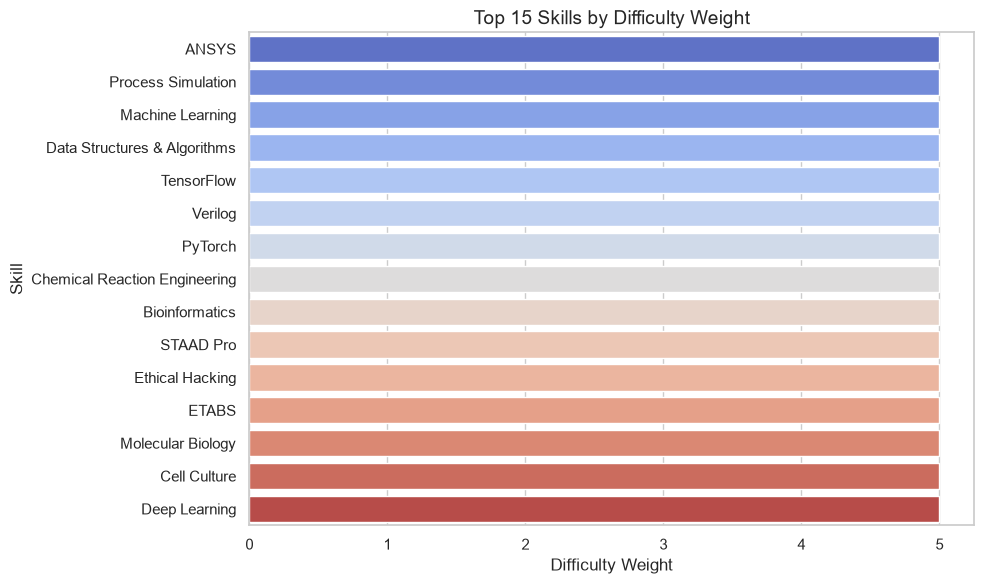

In [86]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=difficulty_analysis.head(15),
    x="DifficultyWeight",
    y="SkillName",
    palette="coolwarm"
)

plt.title("Top 15 Skills by Difficulty Weight")
plt.xlabel("Difficulty Weight")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

## 4. Most Demanded Skills by Companies

## Basic Statistics

In [87]:
company_skill_demand = (
    role_skills
    .merge(
        skills,
        on="SkillID"
    )
)

skill_demand = (
    company_skill_demand["SkillName"]
    .value_counts()
    .reset_index()
)

skill_demand.columns = ["Skill", "Demand"]

skill_demand.head(15)

,Skill,Demand
0,Problem Solving,12
1,SQL,9
2,Python,8
3,Git,7
4,Data Visualization,5
5,Linux,5
6,Communication,5
7,Digital Electronics,4
8,Critical Thinking,4
9,Presentation Skills,4


## Visualization - Bar Plot

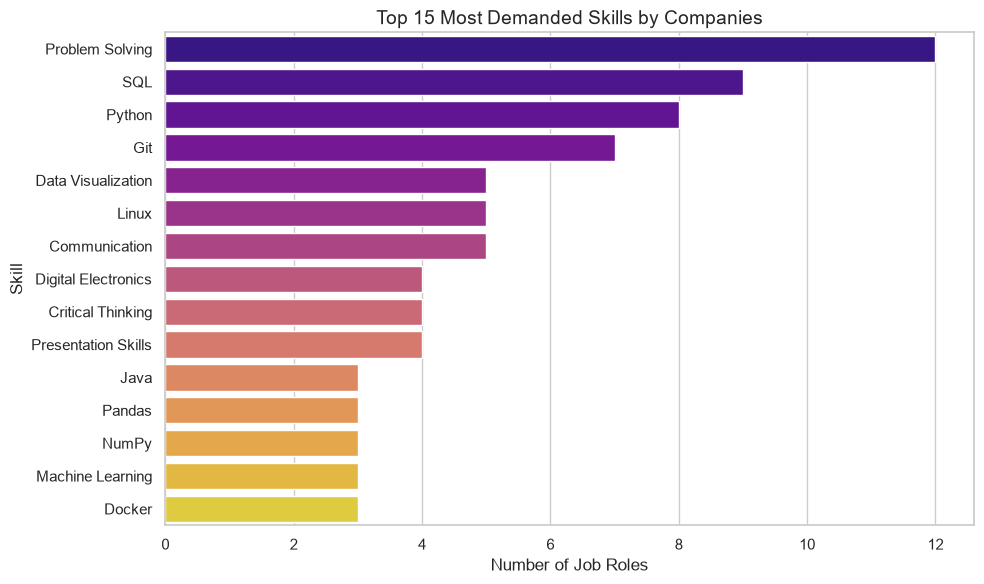

In [88]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=skill_demand.head(15),
    x="Demand",
    y="Skill",
    palette="plasma"
)

plt.title("Top 15 Most Demanded Skills by Companies")
plt.xlabel("Number of Job Roles")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

## Key Findings

- The student skill distribution demonstrates strong coverage across programming, databases, data science, software development, communication, and core engineering domains.
- **Problem Solving** emerges as the most frequently demanded skill by companies, highlighting the importance of analytical thinking and algorithmic ability during technical recruitment.
- **SQL**, **Python**, and **Git** are among the most sought-after technical skills, indicating that companies prioritize database management, programming proficiency, and version control in prospective candidates.
- In addition to technical expertise, companies also place significant emphasis on **Communication**, **Critical Thinking**, and **Presentation Skills**, reflecting the growing importance of professional and interpersonal competencies in the hiring process.
- Skills such as **Data Visualization**, **Linux**, **Machine Learning**, **Docker**, **Pandas**, and **NumPy** demonstrate the industry's increasing demand for data-driven and modern software engineering capabilities.
- Overall, the comparison between student skills and company requirements indicates that the generated dataset closely reflects a realistic campus placement environment, where successful candidates are expected to possess a balanced combination of **technical expertise, problem-solving ability, and professional communication skills**.

## Section 9 - Correlation Analysis

## 1. Create Student Analysis Dataset

In [89]:
student_analysis = (
    students
    .merge(
        placements,
        on="StudentID"
    )
)

## 1.1 Merge the Salary Package

In [90]:
student_analysis = student_analysis.merge(
    company_roles[["CompanyRoleID", "Package"]],
    on="CompanyRoleID",
    how="left"
)

## 1.2 Encode Placement Status

In [91]:
student_analysis = student_analysis.drop(columns=["PlacementStatus_y"])
student_analysis = student_analysis.rename(
    columns={"PlacementStatus_x": "PlacementStatus"}
)

## 1.3 Encode Placement Status

In [92]:
student_analysis["Placement"] = (
    student_analysis["PlacementStatus"]
    .map({
        "Placed": 1,
        "Not Placed": 0
    })
)

## 2. Correlation Matrix

In [93]:
numeric_columns = [
    "CGPA",
    "CodingScore",
    "DSASolved",
    "Projects",
    "Internships",
    "CommunicationScore",
    "AptitudeScore",
    "Package"
]

correlation_matrix = student_analysis[numeric_columns].corr()

## 3. Heatmap

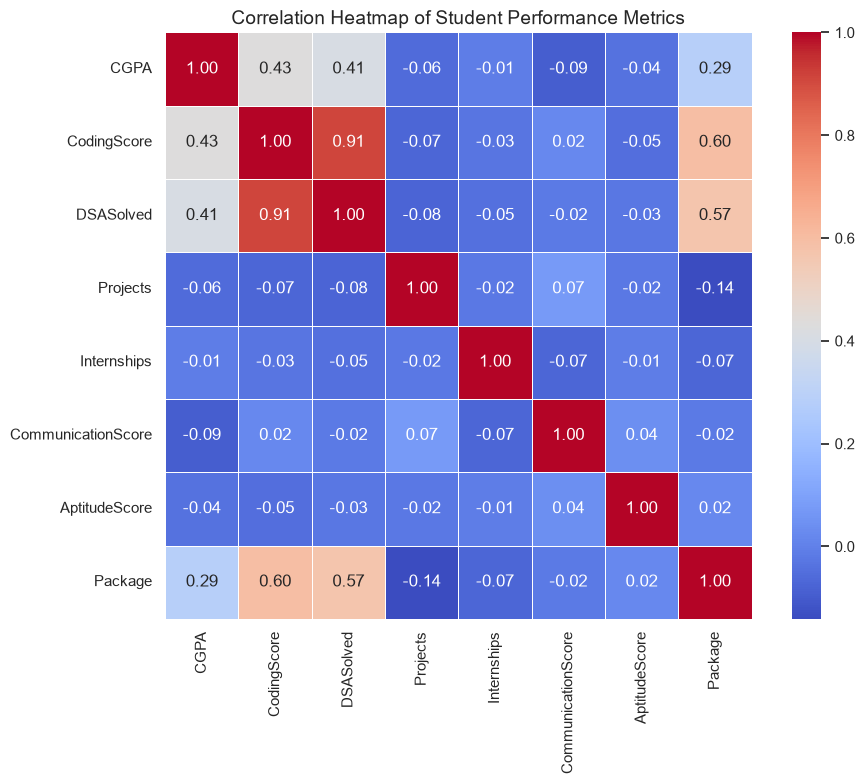

In [94]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Student Performance Metrics")

plt.tight_layout()
plt.show()

## Visualization 1 - CGPA vs Package 

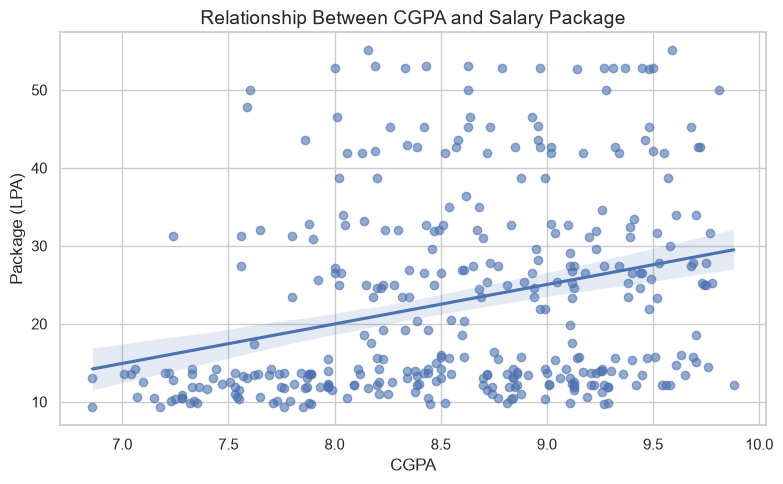

In [95]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=student_analysis,
    x="CGPA",
    y="Package",
    scatter_kws={"alpha":0.6}
)

plt.title("Relationship Between CGPA and Salary Package")
plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")

plt.tight_layout()
plt.show()

## Visualization 2 - Coding Score vs Package 

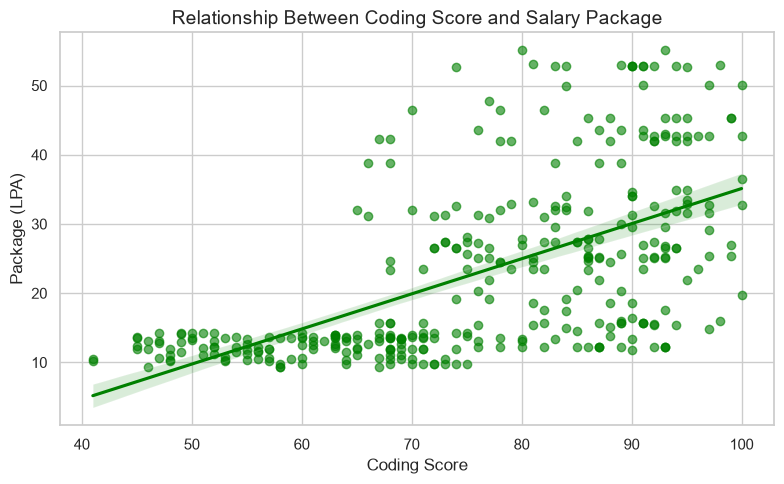

In [96]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=student_analysis,
    x="CodingScore",
    y="Package",
    scatter_kws={"alpha":0.6},
    color="green"
)

plt.title("Relationship Between Coding Score and Salary Package")
plt.xlabel("Coding Score")
plt.ylabel("Package (LPA)")

plt.tight_layout()
plt.show()

### Key Findings

- The correlation analysis reveals a **strong positive relationship (0.91)** between **Coding Score** and **DSA Solved**, indicating that students with stronger programming proficiency generally solve more data structures and algorithms problems.
- **Coding Score (0.60)** exhibits the strongest positive correlation with **Salary Package**, followed closely by **DSA Solved (0.57)**. This suggests that technical competency and problem-solving ability are the most influential factors associated with higher placement offers in the generated dataset.
- **CGPA** shows a **moderate positive correlation (0.29)** with salary package, indicating that academic performance contributes to placement outcomes but is less influential than technical skills.
- **CGPA** also demonstrates moderate positive correlations with both **Coding Score (0.43)** and **DSA Solved (0.41)**, suggesting that academically stronger students tend to perform better in technical assessments.
- **Projects**, **Internships**, **Communication Score**, and **Aptitude Score** exhibit relatively weak linear correlations with salary package, indicating that these factors independently have a smaller impact on compensation within the generated dataset.
- Most feature pairs display low correlation values, indicating minimal multicollinearity. This suggests that each feature captures distinct aspects of a student's academic, technical, or professional profile.
- Overall, the analysis demonstrates that **technical proficiency—particularly coding ability and problem-solving skills—has the strongest association with higher placement packages**, while academic performance serves as a complementary factor in determining placement success.

## Section 10 - Insights & Final Summary

## 1. Major Insights

- The dataset contains a diverse set of students, companies, job roles, and placement records, providing a comprehensive overview of the placement ecosystem.

- Computer Science and related technology branches achieved the highest placement rates, while a few non-technical branches exhibited comparatively lower placement percentages.

- Male and female students demonstrated relatively similar placement performance, indicating no significant gender disparity in placement outcomes within the dataset.

- Software Engineering emerged as the most frequently offered job role, reflecting the continued dominance of software-related hiring across companies.

- Microsoft, JP Morgan Chase, Infosys, Adobe, and Accenture were among the companies offering the highest number of job opportunities.

- Semiconductor, Banking, Consulting, and IT Services represented the most active recruiting industries.

- AI Engineer, Quant Analyst, DevOps Engineer, and VLSI Engineer were identified as the highest-paying job roles.

- NVIDIA, Microsoft, Apple, and JP Morgan Chase offered the highest average salary packages among all participating companies.

- Problem Solving, Python, SQL, Git, and Communication skills were consistently identified as the most frequently demanded skills across job roles.

- Coding Score and DSA performance exhibited stronger relationships with salary packages than CGPA, highlighting the growing importance of technical competency during placements.

## Business Recommendations

- Students should prioritize strengthening coding ability and problem-solving skills, as these demonstrate the strongest association with higher salary packages.

- Placement cells should organize additional technical training programs focused on Data Structures & Algorithms, Python, SQL, Machine Learning, and Cloud technologies to improve placement readiness.

- Academic institutions should encourage project-based learning and industry-oriented skill development alongside traditional coursework.

- Companies may consider expanding hiring opportunities across a broader range of branches to promote interdisciplinary recruitment.

- Career guidance initiatives should educate students about emerging high-paying domains such as Artificial Intelligence, DevOps, Cybersecurity, VLSI, and Cloud Computing.

- Continuous monitoring of industry hiring trends can help institutions align curricula with evolving market demands and improve graduate employability.

## Conclusion

This exploratory data analysis provides valuable insights into student performance, placement trends, company recruitment patterns, salary distributions, and skill requirements within the placement ecosystem.

The analysis demonstrates that technical competencies, particularly coding proficiency and problem-solving ability, are more strongly associated with higher salary packages than academic performance alone. Furthermore, software-oriented roles continue to dominate recruitment, while emerging domains such as Artificial Intelligence, Cloud Computing, DevOps, and Cybersecurity offer some of the highest compensation packages.

Overall, the findings can support students in making informed career decisions, assist placement cells in designing targeted training programs, and help academic institutions align their curricula with evolving industry requirements. These insights also establish a strong analytical foundation for future predictive models, including placement prediction and salary estimation.